In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

import joblib
import shap

pd.set_option(
    "display.max_columns",
    None
)

In [2]:
PROJECT_DIR = Path.cwd().parent

CURATED_DIR = (
    PROJECT_DIR
    / "data"
    / "curated"
)

MODELS_DIR = (
    PROJECT_DIR
    / "models"
)

In [4]:
model_df = pd.read_csv(
    CURATED_DIR
    / "renewal_model_dataset.csv",
    low_memory=False
)

print(model_df.shape)

(19204, 60)


In [5]:
renewal_model = joblib.load(
    MODELS_DIR
    / "renewal_xgboost_model.joblib"
)

In [7]:
renewal_threshold = joblib.load(
    MODELS_DIR
    / "renewal_churn_threshold.joblib"
)

In [8]:
print(
    "Threshold:",
    renewal_threshold
)

Threshold: 0.35


Define the Same Features Used During Training

In [9]:
numeric_features = [
    "AGE",
    "ANNUAL_INCOME",
    "CREDIT_SCORE",

    "SUM_INSURED",
    "ANNUAL_PREMIUM",
    "RISK_SCORE",
    "DISCOUNT_PCT",
    "COMMISSION_PCT",
    "POLICY_TERM_DAYS",
    "PREMIUM_TO_SUM_INSURED_PCT",

    "HEALTH_SCORE",
    "BMI",
    "UNDERWRITING_SCORE",
    "PREMIUM_LOADING_PCT",

    "OLD_PREMIUM",
    "NEW_PREMIUM",
    "PREMIUM_INCREASE_PCT",
    "PREMIUM_CHANGE_AMOUNT",
    "NEW_PREMIUM_TO_INCOME_PCT",
    "LOYALTY_YEARS",

    "TOTAL_DUE_TXNS_PRIOR",
    "PAID_TXNS_PRIOR",
    "UNPAID_TXNS_AT_RENEWAL",
    "TOTAL_PREMIUM_DUE_PRIOR",
    "TOTAL_PREMIUM_PAID_PRIOR",
    "AVG_PAYMENT_DELAY_PRIOR",
    "MAX_PAYMENT_DELAY_PRIOR",
    "PAYMENT_SUCCESS_RATE_PRIOR",

    "TOTAL_CLAIMS_PRIOR",
    "TOTAL_CLAIM_AMOUNT_PRIOR",
    "AVG_CLAIM_AMOUNT_PRIOR",
    "MAX_CLAIM_AMOUNT_PRIOR",
    "DAYS_SINCE_LAST_CLAIM",

    "HAS_PAYMENT_HISTORY_PRIOR",
    "HAS_CLAIM_HISTORY_PRIOR",
    "HAS_UNPAID_PAYMENT_AT_RENEWAL",
    "HAS_UNDERWRITING_RECORD",
    "PREMIUM_INCREASED_FLAG",
    "HIGH_PREMIUM_INCREASE_FLAG"
]

categorical_features = [
    "GENDER",
    "MARITAL_STATUS",
    "OCCUPATION",
    "STATE",
    "CUSTOMER_RISK_SEGMENT",

    "POLICY_TYPE",
    "SALES_CHANNEL",
    "PAYMENT_MODE",
    "RISK_BAND",

    "LIFESTYLE",
    "MEDICAL_HISTORY_FLAG",
    "SMOKER_FLAG",
    "OCCUPATION_RISK",
    "UW_DECISION",

    "CONTACT_CHANNEL"
]

In [18]:
all_features = (numeric_features+categorical_features)

In [17]:
missing_features = [feature for feature in all_features if feature not in model_df.columns]

print("Missing Features:", missing_features)

Missing Features: []


In [19]:
X_score = model_df[
    all_features
].copy()

In [20]:
non_renewal_probability = (
    renewal_model
    .predict_proba(
        X_score
    )[:, 1]
)

In [22]:
# creating score table 
renewal_scores = model_df[
    [
        "POLICY_ID",
        "CUSTOMER_ID"
    ]
].copy()

In [23]:
renewal_scores[
    "NON_RENEWAL_PROBABILITY"
] = non_renewal_probability

In [24]:
renewal_scores.head()

,POLICY_ID,CUSTOMER_ID,NON_RENEWAL_PROBABILITY
0,POL000051250,CUST00059258,0.446941
1,POL000017253,CUST00094235,0.393496
2,POL000108220,CUST00031120,0.481511
3,POL000068626,CUST00061811,0.269972
4,POL000134055,CUST00024866,0.502176


In [25]:
renewal_scores["NON_RENEWAL_RISK_PCT"] = (
    renewal_scores["NON_RENEWAL_PROBABILITY"] * 100
).round(2)

In [26]:
renewal_scores["HIGH_RISK_FLAG"] = (
    renewal_scores["NON_RENEWAL_PROBABILITY"] >= renewal_threshold
).astype(int)

In [27]:
medium_cutoff = renewal_threshold / 2

In [29]:
renewal_scores["RISK_BAND"] = np.select(
    [
        renewal_scores["NON_RENEWAL_PROBABILITY"] >= renewal_threshold,
        renewal_scores["NON_RENEWAL_PROBABILITY"] >= medium_cutoff
    ],
    [
        "High",
        "Medium"
    ],
    default="Low"
)

In [30]:
renewal_scores[
    "RISK_BAND"
].value_counts()

RISK_BAND
High      13017
Medium     5598
Low         589
Name: count, dtype: int64

In [31]:
renewal_scores["RISK_BAND"].value_counts(normalize=True).mul(100).round(2)

RISK_BAND
High      67.78
Medium    29.15
Low        3.07
Name: proportion, dtype: float64

In [32]:
renewal_scores["RISK_RANK"] = renewal_scores["NON_RENEWAL_PROBABILITY"].rank(method="first", ascending=False).astype(int)

In [33]:
renewal_scores = renewal_scores.sort_values("NON_RENEWAL_PROBABILITY", ascending=False)

In [34]:
renewal_scores.head(20)

,POLICY_ID,CUSTOMER_ID,NON_RENEWAL_PROBABILITY,NON_RENEWAL_RISK_PCT,HIGH_RISK_FLAG,RISK_BAND,RISK_RANK
6502,POL000068562,CUST00067173,0.869240,86.919998,1,High,1
17486,POL000135858,CUST00083885,0.859707,85.970001,1,High,2
18613,POL000069106,CUST00025105,0.846694,84.669998,1,High,3
2152,POL000115705,CUST00073616,0.845394,84.540001,1,High,4
726,POL000004904,CUST00020605,0.844151,84.419998,1,High,5
12484,POL000051704,CUST00025568,0.842616,84.260002,1,High,6
13093,POL000146506,CUST00022426,0.835587,83.559998,1,High,7
11970,POL000023925,CUST00094517,0.831712,83.169998,1,High,8
29,POL000002039,CUST00004191,0.824270,82.430000,1,High,9
12999,POL000030288,CUST00037155,0.822090,82.209999,1,High,10


In [35]:
renewal_scores["ACTUAL_NON_RENEWAL_FLAG"] = model_df["NON_RENEWAL_FLAG"].values

In [36]:
risk_validation = (
    renewal_scores
    .groupby("RISK_BAND")
    .agg(
        POLICIES=("POLICY_ID", "count"),
        ACTUAL_NON_RENEWALS=("ACTUAL_NON_RENEWAL_FLAG", "sum"),
        AVG_PREDICTED_RISK=("NON_RENEWAL_PROBABILITY", "mean"),
        ACTUAL_NON_RENEWAL_RATE=("ACTUAL_NON_RENEWAL_FLAG", "mean")
    )
    .reset_index()
)

In [37]:
risk_validation["AVG_PREDICTED_RISK"] *= 100
risk_validation["ACTUAL_NON_RENEWAL_RATE"] *= 100

risk_validation.round(2)

,RISK_BAND,POLICIES,ACTUAL_NON_RENEWALS,AVG_PREDICTED_RISK,ACTUAL_NON_RENEWAL_RATE
0,High,13017,1293,48.27,9.93
1,Low,589,52,12.97,8.83
2,Medium,5598,525,28.42,9.38


In [38]:
preprocessor = renewal_model.named_steps["preprocessor"]

In [39]:
xgb_model = renewal_model.named_steps["model"]

In [40]:
feature_names = (
    preprocessor
    .get_feature_names_out()
)

In [41]:
feature_names[:20]

array(['num__AGE', 'num__ANNUAL_INCOME', 'num__CREDIT_SCORE',
       'num__SUM_INSURED', 'num__ANNUAL_PREMIUM', 'num__RISK_SCORE',
       'num__DISCOUNT_PCT', 'num__COMMISSION_PCT',
       'num__POLICY_TERM_DAYS', 'num__PREMIUM_TO_SUM_INSURED_PCT',
       'num__HEALTH_SCORE', 'num__BMI', 'num__UNDERWRITING_SCORE',
       'num__PREMIUM_LOADING_PCT', 'num__OLD_PREMIUM', 'num__NEW_PREMIUM',
       'num__PREMIUM_INCREASE_PCT', 'num__PREMIUM_CHANGE_AMOUNT',
       'num__NEW_PREMIUM_TO_INCOME_PCT', 'num__LOYALTY_YEARS'],
      dtype=object)

In [42]:
X_explain = X_score.sample(n=min(1000, len(X_score)), random_state=42)

In [43]:
X_explain_transformed = preprocessor.transform(X_explain)



In [44]:
if hasattr(X_explain_transformed, "toarray"):
    X_explain_transformed = X_explain_transformed.toarray()

In [45]:
explainer = shap.TreeExplainer(xgb_model)

In [46]:
shap_values = explainer( X_explain_transformed)

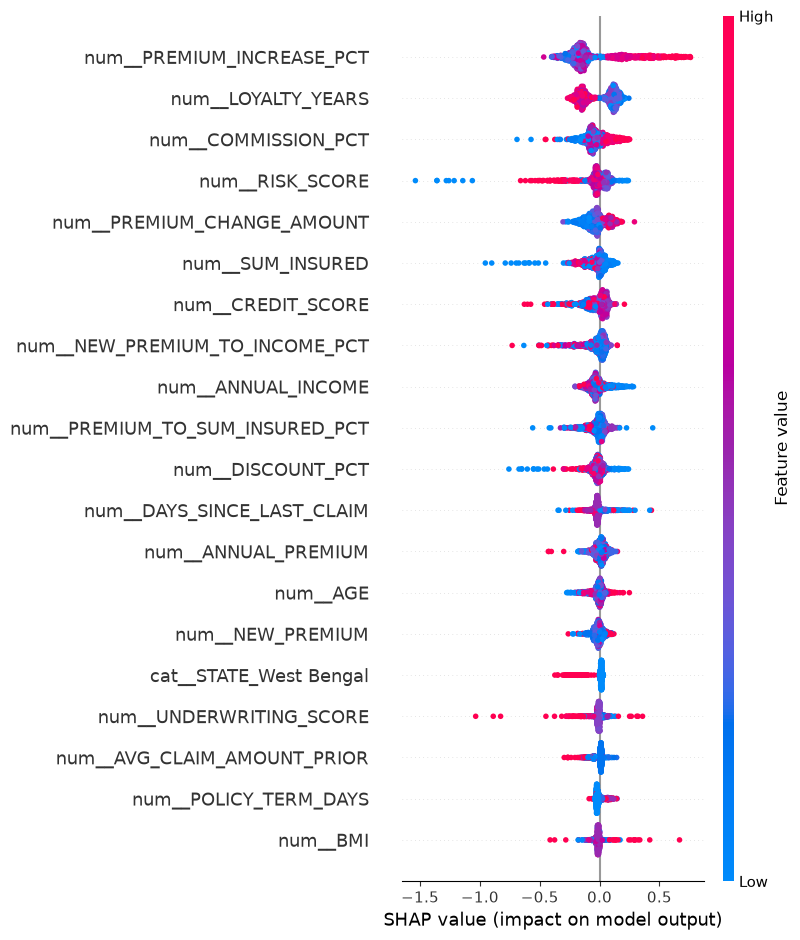

In [47]:
shap.summary_plot( shap_values.values,X_explain_transformed,feature_names=feature_names)

In [48]:
highest_risk_index = (renewal_scores.index[0])

In [49]:
single_customer = X_score.loc[
    [highest_risk_index]
]

In [50]:
single_transformed = preprocessor.transform(single_customer)

if hasattr(single_transformed, "toarray"):
    single_transformed = single_transformed.toarray()

In [51]:
single_shap = explainer(single_transformed)

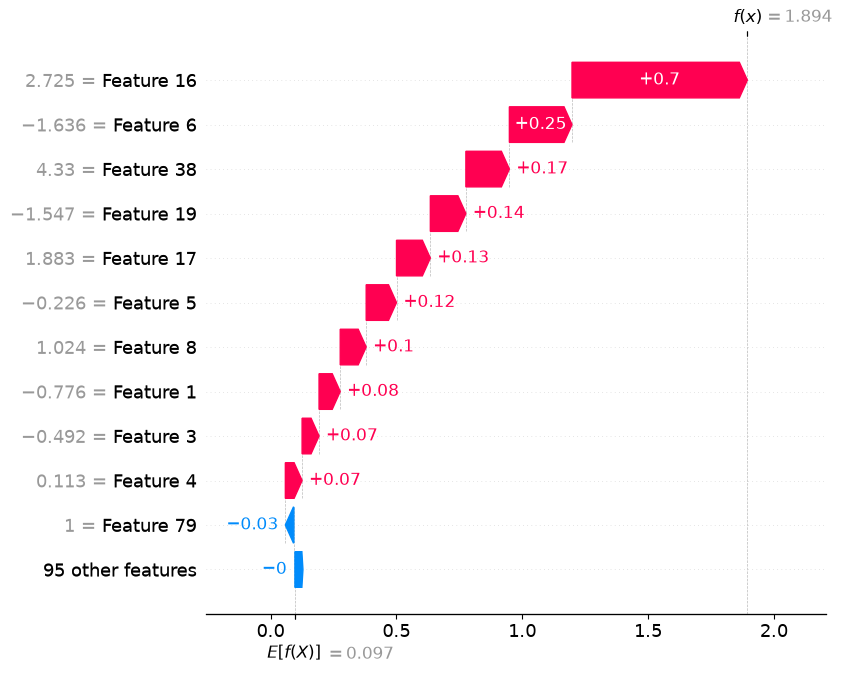

In [52]:
shap.plots.waterfall(single_shap[0],max_display=12)

In [53]:
def clean_feature_name(name):
    name = name.replace("num__", "")
    name = name.replace("cat__", "")
    return name

In [54]:
def get_top_risk_drivers(row, model_pipeline, explainer, top_n=3):

    # Get preprocessor
    preprocessor = model_pipeline.named_steps["preprocessor"]

    # Get feature names
    feature_names = preprocessor.get_feature_names_out()

    # Transform customer data
    transformed = preprocessor.transform(row)

    # Convert sparse matrix to normal array
    if hasattr(transformed, "toarray"):
        transformed = transformed.toarray()

    # Calculate SHAP values
    explanation = explainer(transformed)
    shap_values = explanation.values[0]

    # Create dataframe
    driver_df = pd.DataFrame({
        "FEATURE": feature_names,
        "SHAP_VALUE": shap_values
    })

    # Keep only features increasing non-renewal risk
    driver_df = driver_df[driver_df["SHAP_VALUE"] > 0]

    # Select top risk drivers
    driver_df = driver_df.sort_values(
        "SHAP_VALUE",
        ascending=False
    ).head(top_n)

    # Clean feature names
    driver_df["FEATURE"] = driver_df["FEATURE"].apply(clean_feature_name)

    return driver_df

In [55]:
sample_row = X_score.iloc[[0]]

get_top_risk_drivers(
    sample_row,
    renewal_model,
    explainer,
    top_n=3
)

,FEATURE,SHAP_VALUE
8,POLICY_TERM_DAYS,0.061536
3,SUM_INSURED,0.055141
9,PREMIUM_TO_SUM_INSURED_PCT,0.039439


In [56]:
def retention_action(risk_band):

    if risk_band == "High":
        return "Priority retention review"

    elif risk_band == "Medium":
        return "Digital reminder / monitor"

    else:
        return "Standard renewal journey"

In [57]:
renewal_scores["RECOMMENDED_ACTION"] = renewal_scores["RISK_BAND"].apply(retention_action)

In [58]:
business_cols = model_df[
    [
        "POLICY_ID",
        "POLICY_TYPE",
        "STATE",
        "NEW_PREMIUM",
        "PREMIUM_INCREASE_PCT",
        "LOYALTY_YEARS",
        "CONTACT_CHANNEL"
    ]
].copy()

In [59]:
retention_priority = (
    renewal_scores
    .merge(
        business_cols,
        on="POLICY_ID",
        how="left",
        validate="one_to_one"
    )
)

In [60]:
retention_priority = retention_priority[
    [
        "POLICY_ID",
        "CUSTOMER_ID",
        "POLICY_TYPE",
        "STATE",

        "NON_RENEWAL_RISK_PCT",
        "RISK_BAND",
        "RISK_RANK",

        "NEW_PREMIUM",
        "PREMIUM_INCREASE_PCT",
        "LOYALTY_YEARS",

        "CONTACT_CHANNEL",

        "RECOMMENDED_ACTION",

        "ACTUAL_NON_RENEWAL_FLAG"
    ]
]

In [61]:
retention_priority = (retention_priority.sort_values("RISK_RANK" ))

In [62]:
retention_priority.head(20)

,POLICY_ID,CUSTOMER_ID,POLICY_TYPE,STATE,NON_RENEWAL_RISK_PCT,RISK_BAND,RISK_RANK,NEW_PREMIUM,PREMIUM_INCREASE_PCT,LOYALTY_YEARS,CONTACT_CHANNEL,RECOMMENDED_ACTION,ACTUAL_NON_RENEWAL_FLAG
0,POL000068562,CUST00067173,Health,Telangana,86.919998,High,1,25276,20.41,1,WhatsApp,Priority retention review,0
1,POL000135858,CUST00083885,Motor,Kerala,85.970001,High,2,17649,17.27,7,Call,Priority retention review,0
2,POL000069106,CUST00025105,Personal Accident,Karnataka,84.669998,High,3,4807,16.24,4,SMS,Priority retention review,0
3,POL000115705,CUST00073616,Health,Kerala,84.540001,High,4,29107,12.59,2,SMS,Priority retention review,0
4,POL000004904,CUST00020605,Whole Life,Gujarat,84.419998,High,5,59433,15.76,2,Call,Priority retention review,0
5,POL000051704,CUST00025568,Whole Life,Rajasthan,84.260002,High,6,97404,13.23,1,WhatsApp,Priority retention review,1
6,POL000146506,CUST00022426,Motor,West Bengal,83.559998,High,7,17274,23.59,6,SMS,Priority retention review,0
7,POL000023925,CUST00094517,Motor,Karnataka,83.169998,High,8,17538,16.38,5,WhatsApp,Priority retention review,0
8,POL000002039,CUST00004191,Travel,Maharashtra,82.430000,High,9,3801,13.84,2,SMS,Priority retention review,0
9,POL000030288,CUST00037155,Health,Telangana,82.209999,High,10,37890,15.42,1,Agent Visit,Priority retention review,0


In [63]:
campaign_capacity = 500

In [64]:
priority_campaign = retention_priority.head(campaign_capacity).copy()

priority_campaign["ACTUAL_NON_RENEWAL_FLAG"].mean()

np.float64(0.1)

In [65]:
def precision_at_k(scores_df, k):

    top_k = scores_df.sort_values(
        "NON_RENEWAL_PROBABILITY",
        ascending=False
    ).head(k)

    return top_k["ACTUAL_NON_RENEWAL_FLAG"].mean()

In [66]:
for k in [100, 250, 500, 1000]:

    result = precision_at_k(renewal_scores, k)

    print(f"Precision@{k}:", round(result, 4))

Precision@100: 0.13
Precision@250: 0.1
Precision@500: 0.1
Precision@1000: 0.108


In [67]:
def recall_at_k(scores_df, k):

    # Top K highest-risk customers
    top_k = scores_df.sort_values(
        "NON_RENEWAL_PROBABILITY",
        ascending=False
    ).head(k)

    # Top K mein kitne actual non-renewers pakde
    caught_non_renewals = top_k["ACTUAL_NON_RENEWAL_FLAG"].sum()

    # Total actual non-renewers
    total_non_renewals = scores_df["ACTUAL_NON_RENEWAL_FLAG"].sum()

    # Recall@K
    return caught_non_renewals / total_non_renewals




In [68]:
for k in [100, 250, 500, 1000]:

    result = recall_at_k(renewal_scores, k)

    print(f"Recall@{k}:", round(result, 4))

Recall@100: 0.007
Recall@250: 0.0134
Recall@500: 0.0267
Recall@1000: 0.0578


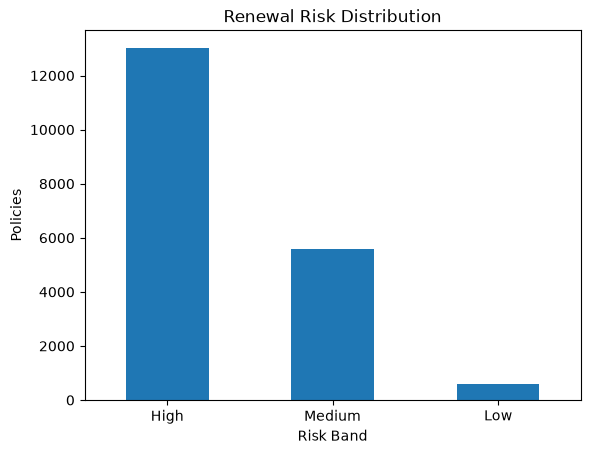

In [69]:
risk_counts = renewal_scores["RISK_BAND"].value_counts()

risk_counts.plot(kind="bar")

plt.title("Renewal Risk Distribution")
plt.xlabel("Risk Band")
plt.ylabel("Policies")
plt.xticks(rotation=0)

plt.show()

In [70]:
risk_comparison = renewal_scores.groupby("RISK_BAND").agg(
    AVG_PREDICTED_RISK=("NON_RENEWAL_PROBABILITY", "mean"),
    ACTUAL_NON_RENEWAL_RATE=("ACTUAL_NON_RENEWAL_FLAG", "mean")
)

In [71]:
risk_comparison *= 100

risk_comparison.round(2)

,AVG_PREDICTED_RISK,ACTUAL_NON_RENEWAL_RATE
RISK_BAND,,
High,48.27,9.93
Low,12.97,8.83
Medium,28.42,9.38


In [72]:
SCORES_DIR = (
    PROJECT_DIR
    / "data"
    / "curated"
)

In [73]:
retention_priority.to_csv(
    SCORES_DIR
    / "renewal_risk_scores.csv",
    index=False
)